In [8]:
import numpy as np
import pandas as pd
from numpy.fft import fft
from matplotlib import pyplot as plt
import math
import warnings,os
import glob
from scipy.signal import find_peaks
warnings.filterwarnings('ignore')

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# import zipfile
# import os

# zip_path = "jan_7_data_discretized.zip"  # Replace with your uploaded zip file name
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall("data")  # Replace with your desired directory



In [ ]:
path="/home/do-gon/acoustic_docker/vibecheck_ws/classification/data/contact_type/2025-2-22/feb_22_demo_data/test_set/"
folder_list = os.listdir(path)

In [10]:
folder_list

['one_line_9',
 'diagonal_2',
 'in_hole_8',
 'diagonal_6',
 'one_line_1',
 'in_hole_3',
 'in_hole_10',
 'one_line_5',
 'diagonal_4',
 'in_hole_9',
 'diagonal_5',
 'in_hole_4',
 'one_line_8',
 'one_line_2',
 'in_hole_2',
 'one_line_10',
 'diagonal_10',
 'diagonal_3',
 'diagonal_7',
 'in_hole_7',
 'diagonal_1',
 'one_line_3',
 'one_line_6',
 'in_hole_1',
 'one_line_7',
 'in_hole_5',
 'in_hole_6',
 'one_line_4',
 'diagonal_9',
 'diagonal_8']

Import dataset

In [5]:
# file_size=10
# def get_data(raw_data):
#   data=raw_data.drop(["msg"],axis=1)
#   rot_data = data
#   return rot_data
# # concate all data to single file
# for name_idx in range(len(folder_list)):
#   df=[]
#   for i in range(1,file_size+1):
#     material=path+folder_list[name_idx]
#     filename="/output_"+str(i)+".csv"
#     temp=pd.read_csv(material+filename)
#     temp=get_data(temp) # remove the unuse columns
#     row_data=[]
#     for row in range (len(temp)):
#       row_data.append(temp.iloc[row].values)
#     row_data=np.array(row_data).reshape((1,-1)).squeeze(axis=0)
#     df.append(row_data)
#   df=pd.DataFrame(df)
#   material=path+folder_list[name_idx]
#   df.transpose().to_csv(material+"/all_result.csv")
#   print("finish"+folder_list[name_idx])

In [6]:
import random
def print_original_plot(name,path,outlier_delete=False):
  material=path+name
  filename="/all_result.csv"
  df=pd.read_csv(material+filename)
  df=df.dropna(axis=0) # drop the unconsistent data long
  df=df.drop(list(df)[0],axis=1)
  # print(df.describe())
  if outlier_delete:
    randomlist = random.sample(range(0, len(df)), 1000)
    for i in randomlist:
      mean = df.iloc[i].mean()
      std = df.iloc[i].std()

      z_scores = (df.iloc[i] - mean) / std

      mask = np.abs(z_scores) > 5
      # print(mask)
      drop_col=[]
      for i in range(len(mask)):
        if mask[i]:
          drop_col.append(df.columns[i])
      df.drop(drop_col,axis=1, inplace=True)

  # print(df.shape)
  # # print(df)
  # df.plot(kind='line',alpha=0.5, figsize=(10, 4),title=name+' orignal data plot',legend=False)
  # df.plot(kind='hist',alpha=0.5, figsize=(10, 10),title=name+" orignal data plot",legend=False)
  return df

In [ ]:
path="/home/do-gon/acoustic_docker/vibecheck_ws/classification/data/contact_type/combined/train_feb_1_feb_2_feb_11_feb_13_feb_16_test_feb_2_feb_3_feb_11_feb_21_demo_data/train_set/"
folder_list = os.listdir(path)
df_all=pd.DataFrame()
# labellist=['alu_hollow_thick','alu_hollow_thin','alu','brass_hollow','brass','printpla','pla','printresin','wood']
# labellist=['brass_hollow','brass','printpla','pla','printresin','wood']
# labellist=['alu','brass','printpla','pla','printresin','wood']
# labellist=folder_list
# labellist=['center','edge','middle']
# labellist=['full','stand','point']
# labellist=['1','2']

labellist=['diagonal','one_line','in_hole']

for name in folder_list:
  df_temp=print_original_plot(name=name,path=path)
  label=""
  for i in labellist:
    if i in name :
      label=i
      break
  if (label==''): continue
  print(label,name)
  df_temp.loc['label']=[labellist.index(label) for _ in list(df_temp)]
  df_all = pd.concat([df_all, df_temp], axis=1)


one_line one_line_9
diagonal diagonal_2
in_hole in_hole_8
diagonal diagonal_6
one_line one_line_1
in_hole in_hole_3
in_hole in_hole_10
one_line one_line_5
diagonal diagonal_4
in_hole in_hole_9
diagonal diagonal_5
in_hole in_hole_4
one_line one_line_8
one_line one_line_2
in_hole in_hole_2
one_line one_line_10
diagonal diagonal_10
diagonal diagonal_3
diagonal diagonal_7
in_hole in_hole_7
diagonal diagonal_1
one_line one_line_3
one_line one_line_6
in_hole in_hole_1
one_line one_line_7
in_hole in_hole_5
in_hole in_hole_6
one_line one_line_4
diagonal diagonal_9
diagonal diagonal_8


In [ ]:
df_all2=pd.DataFrame()
path_2="/home/do-gon/acoustic_docker/vibecheck_ws/classification/data/contact_type/2025-2-22/feb_22_demo_data/test_set/"
folder_list_2 = os.listdir(path_2)
for name in folder_list_2:
  # if ('2' in name ): continue
  df_temp=print_original_plot(name=name,path=path_2)
  label=""
  for i in labellist:
    if i in name :
      label=i
      break
  if (label==''): continue
  print(label,name)
  df_temp.loc['label']=[labellist.index(label) for _ in list(df_temp)]
  df_all2 = pd.concat([df_all2, df_temp], axis=1,ignore_index=True)

one_line one_line_9
diagonal diagonal_2
in_hole in_hole_8
diagonal diagonal_6
one_line one_line_1
in_hole in_hole_3
in_hole in_hole_10
one_line one_line_5
diagonal diagonal_4
in_hole in_hole_9
diagonal diagonal_5
in_hole in_hole_4
one_line one_line_8
one_line one_line_2
in_hole in_hole_2
one_line one_line_10
diagonal diagonal_10
diagonal diagonal_3
diagonal diagonal_7
in_hole in_hole_7
diagonal diagonal_1
one_line one_line_3
one_line one_line_6
in_hole in_hole_1
one_line one_line_7
in_hole in_hole_5
in_hole in_hole_6
one_line one_line_4
diagonal diagonal_9
diagonal diagonal_8


In [12]:
df_all=df_all.dropna(axis=0)
df_all2=df_all2.dropna(axis=0)


In [13]:
df_all

,0,1,2,3,4,5,6,7,8,9,...,450,451,452,453,454,455,456,457,458,459
0,22.0,55.0,-2.0,22.0,30.0,2.0,-5.0,-3.0,-105.0,-9.0,...,101.0,1.0,11.0,-8.0,-7.0,-27.0,58.0,87.0,76.0,-17.0
1,27.0,49.0,-1.0,18.0,31.0,-3.0,0.0,3.0,-106.0,-9.0,...,105.0,0.0,9.0,-8.0,-7.0,-28.0,56.0,83.0,75.0,-12.0
2,24.0,49.0,7.0,19.0,28.0,2.0,1.0,-1.0,-107.0,-10.0,...,106.0,0.0,13.0,-9.0,-6.0,-25.0,54.0,89.0,76.0,-13.0
3,27.0,54.0,5.0,20.0,30.0,5.0,-7.0,4.0,-105.0,-12.0,...,103.0,1.0,9.0,-10.0,-8.0,-31.0,55.0,90.0,77.0,-13.0
4,25.0,47.0,5.0,21.0,30.0,-2.0,2.0,-1.0,-102.0,-9.0,...,100.0,-3.0,11.0,-7.0,-7.0,-31.0,54.0,89.0,76.0,-11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44028,-75.0,44.0,-36.0,15.0,54.0,-6.0,-12.0,33.0,37.0,5.0,...,-11.0,-35.0,32.0,-43.0,39.0,27.0,30.0,-21.0,21.0,-30.0
44029,93.0,-104.0,25.0,-33.0,-70.0,-5.0,5.0,-42.0,-12.0,-15.0,...,21.0,46.0,-29.0,33.0,-35.0,-14.0,-31.0,14.0,-26.0,18.0
44030,-99.0,149.0,-36.0,36.0,71.0,13.0,9.0,50.0,3.0,17.0,...,-36.0,-41.0,24.0,-57.0,15.0,-11.0,8.0,9.0,18.0,-39.0
44031,94.0,-186.0,18.0,-37.0,-75.0,-26.0,-16.0,-48.0,23.0,-33.0,...,39.0,40.0,-18.0,34.0,-6.0,27.0,-6.0,-15.0,-22.0,16.0


In [14]:
df_all2
# print(df_all2.loc['label', 10:20])

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,133.0,24.0,-28.0,-36.0,3.0,-22.0,-2.0,-46.0,-42.0,198.0,...,0.0,49.0,6.0,-115.0,-6.0,32.0,32.0,4.0,4.0,22.0
1,138.0,25.0,-26.0,-37.0,6.0,-16.0,-4.0,-44.0,-39.0,194.0,...,1.0,48.0,2.0,-110.0,-6.0,32.0,30.0,-10.0,0.0,21.0
2,133.0,35.0,-13.0,-41.0,5.0,-25.0,-3.0,-48.0,-35.0,191.0,...,3.0,42.0,3.0,-114.0,-9.0,31.0,36.0,-7.0,3.0,25.0
3,129.0,35.0,-5.0,-39.0,6.0,-27.0,-3.0,-42.0,-42.0,192.0,...,4.0,42.0,3.0,-115.0,-5.0,34.0,32.0,2.0,-1.0,22.0
4,135.0,38.0,6.0,-43.0,7.0,-22.0,-5.0,-46.0,-30.0,191.0,...,-2.0,44.0,3.0,-110.0,-9.0,32.0,33.0,0.0,-3.0,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44028,-51.0,44.0,32.0,-22.0,-27.0,31.0,42.0,14.0,-17.0,30.0,...,28.0,29.0,44.0,-42.0,-23.0,76.0,27.0,62.0,-55.0,-30.0
44029,44.0,-54.0,-32.0,27.0,31.0,-25.0,-56.0,-40.0,11.0,-56.0,...,-39.0,-26.0,-47.0,37.0,5.0,-76.0,-35.0,-67.0,13.0,14.0
44030,-45.0,15.0,39.0,-38.0,-40.0,20.0,57.0,25.0,14.0,10.0,...,55.0,24.0,47.0,-44.0,-49.0,54.0,40.0,48.0,2.0,-25.0
44031,28.0,-28.0,-32.0,38.0,41.0,1.0,-60.0,-52.0,-19.0,-29.0,...,-54.0,-11.0,-46.0,33.0,22.0,-42.0,-42.0,-37.0,-41.0,10.0


In [15]:
# def fft_self(df):
#     data_rows = df.iloc[:-1, :]  # All rows except the last
#     label_row = df.iloc[-1, :]    # Last row (label)

#     # Apply FFT on each column except the last row
#     fft_result = data_rows.apply(lambda col: np.abs(np.fft.fft(col)), axis=0)

#     # Append the label row to the FFT result
#     fft_result.loc['label'] = label_row
#     return fft_result

def fft_self(df):
    data_rows = df.iloc[:-1, :]  # All rows except the last
    label_row = df.iloc[-1, :]    # Last row (label)

    # Apply FFT on each column except the last row
    fft_result = data_rows.apply(lambda col: np.abs(np.fft.fft(col)[:8750]), axis=0)
    # fft_result = data_rows.apply(lambda col: np.abs(np.fft.fft(col).real[:2000]), axis=0)
    # fft2200=np.fft.fftfreq(d=1/44100,n=data_rows.shape[0])
    # print(fft2200.shape,fft2200[2000])
    # Append the label row to the FFT result
    fft_result.loc['label'] = label_row
    return fft_result

In [16]:
df_all = pd.concat([df_all.iloc[:42000], df_all.iloc[[-1]]], axis=0,ignore_index = True)
df_all2 = pd.concat([df_all2.iloc[:42000], df_all2.iloc[[-1]]], axis=0,ignore_index = True)
df_all=fft_self(df_all)
df_all2=fft_self(df_all2)

1

In [ ]:
# def positive_find_peak(df):
#     df.columns=[i for i in range(df.shape[1])]
#     data_rows = df.iloc[:-1, :]  # All rows except the last
#     label_row = df.iloc[-1, :]    # Last row (label)
#     def pfp(singleCol):
#         data_positive=np.abs(singleCol)
#         peaks_idx,_=find_peaks(data_positive)
#         return data_positive[peaks_idx]
#     new=pd.DataFrame()
#     for column in data_rows:
#         data=np.array(data_rows[column])
#         df_temp=pd.DataFrame(pfp(data))
#         new = pd.concat([new, df_temp], axis=1,ignore_index=True)

#     new.loc['label']=label_row
#     # print(new)
#     return new

In [ ]:
# df_=positive_find_peak(df_all.copy())
# df_drop=df_.dropna(axis=0)
# df_all=pd.concat([df_drop.iloc[:11000], df_drop.iloc[[-1]]], axis=0)

# df_=positive_find_peak(df_all2.copy())
# df_drop=df_.dropna(axis=0)
# df_all2=pd.concat([df_drop.iloc[:11000], df_drop.iloc[[-1]]], axis=0)

In [45]:
df_all

,0,1,2,3,4,5,6,7,8,9,...,450,451,452,453,454,455,456,457,458,459
0,20974.000000,16621.000000,16118.000000,26208.000000,21402.000000,16681.000000,19762.000000,14995.000000,27658.000000,15255.000000,...,61151.000000,45217.000000,82648.000000,85335.000000,74705.000000,22075.000000,33562.000000,81416.000000,20772.000000,33965.000000
1,1295.465849,4037.528378,5442.321688,5812.800669,2485.915296,4288.838292,3370.717259,4421.057801,8279.047258,4716.227613,...,38611.149255,23331.324196,59831.747931,66923.484928,51306.687520,6387.410815,15899.232383,59820.014544,2098.233693,12957.396956
2,8301.687472,5052.232109,2355.727122,3680.522203,1274.980141,5159.352952,1598.043183,4373.258707,9628.690827,6725.433989,...,43401.271684,25702.954930,66098.521229,79015.174243,58671.480575,5818.312326,14903.336364,70505.473229,9733.463101,12101.848776
3,11814.343613,5969.431803,3546.162538,6224.783605,1375.721051,4340.607404,5229.295132,6381.456901,10482.109051,5716.120186,...,44133.162839,29872.766292,75936.584261,65599.657330,68147.749470,6651.639088,19694.647845,53943.645515,7389.491820,16840.858786
4,8030.643880,4990.164518,3612.131833,2346.404084,2149.439782,6723.522895,3803.546612,6265.765360,18418.507403,7501.557666,...,39863.946250,27813.183361,69450.424668,70421.936606,56906.519127,1919.844268,16394.612711,83082.604795,2919.336468,9880.309057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8746,40330.606111,43243.236064,40578.943836,35004.097177,43036.480703,41423.851110,41169.521660,40421.572195,42646.974616,36232.011675,...,33592.865401,36617.551927,33040.348458,18742.874842,31128.726797,36304.819422,39550.932507,26975.004547,36993.922253,35191.514026
8747,41172.390440,42654.607949,40393.943719,34612.210988,42679.191543,41574.878372,40805.177599,40346.492117,42979.644656,35826.345114,...,33682.714748,36242.642440,32836.366448,19560.094093,31170.993452,36433.609009,39784.830117,27127.338207,37360.036982,36149.273361
8748,40716.706181,41898.737501,40073.958687,35510.020477,41210.812801,40593.554332,40883.927095,39654.406779,42208.161374,35679.779914,...,33749.680156,36284.992874,33080.219222,18747.657523,31062.712044,36427.741888,40024.330555,26795.704273,37074.957138,35713.640650
8749,40480.060053,42733.045781,40082.999510,35603.811117,42549.728298,41283.556921,41104.169186,40361.211087,43125.651805,36174.695253,...,33931.096418,35738.806757,33389.335402,18960.106462,31840.497711,35539.117333,39982.950326,26387.803623,37453.177000,35163.312257


In [92]:
# print(df_all.shape)

In [46]:
df_all2

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,53717.000000,62294.000000,24945.000000,39515.000000,27580.000000,45921.000000,45274.000000,62411.000000,9736.000000,40953.000000,...,87822.000000,94182.000000,200682.000000,205441.000000,97784.000000,98511.000000,89036.000000,75696.000000,101207.000000,81646.000000
1,29571.338101,41393.805739,13028.803052,19460.326665,7324.945712,26067.229542,31188.914741,41967.323912,12687.870481,19245.715496,...,70188.317673,78400.012894,187417.398147,179537.675188,78486.748154,80976.035337,66372.042818,56078.051245,83836.190479,64720.617174
2,38407.638433,44965.169869,15848.054123,33139.088876,12692.985429,26185.800301,48115.234713,46335.880955,15639.904651,32542.935288,...,69184.920642,71581.497400,171646.773578,192621.523936,91592.657711,87062.097365,72180.879838,63776.745304,91381.055575,61369.386209
3,34909.426405,47557.129997,24333.763122,39136.950002,12523.614822,27564.415552,55255.799730,42493.752770,14124.398501,36435.947201,...,86654.788662,87277.132942,213608.213143,247721.290440,93359.739668,86409.941010,80340.863940,63747.948830,93769.103219,88227.974433
4,61783.506938,44307.361456,17934.263430,42797.558017,13682.045056,31309.903263,62750.784928,42578.326944,13577.453956,17227.754451,...,70532.108672,81468.349625,281734.665052,258020.410627,85814.125213,96735.007796,81852.734811,71443.515267,92192.888414,60460.495849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8746,29390.356687,29883.051266,25284.550841,38261.496793,30360.489024,36576.543046,40242.609140,35707.700381,35518.107076,33431.484862,...,36785.781345,36712.692446,34727.759154,35559.615238,34019.241446,39629.249606,38157.158914,35767.387227,35616.933495,31392.993109
8747,29738.257839,29268.898608,24207.586407,36964.810234,30378.207831,35894.299143,40112.385849,35178.933594,34756.280808,33356.262891,...,35956.303585,36583.220355,33110.909491,35290.348497,33010.217627,39798.273954,38342.847273,34864.418030,35579.061215,31548.878594
8748,29269.727299,28700.930420,24798.203464,37430.615107,30740.126406,35919.233012,40215.150635,34832.437283,36348.333506,33275.144440,...,35233.463882,35264.111920,32959.336723,35569.311396,32731.363936,39764.477619,38341.906589,35536.099873,34970.410103,31104.177023
8749,29930.338387,30833.837473,24778.368878,38695.044442,31196.925185,36219.440244,39372.623729,35239.043674,35971.492458,33502.431882,...,36843.019449,37091.606571,34347.682977,35621.116887,34227.984266,40264.434004,38217.039076,35830.718031,36312.117338,32654.877163


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import KernelPCA
from sklearn.neural_network import MLPClassifier

In [ ]:
import os

# Define the path to the test set folder
test_set_path = "/home/do-gon/acoustic_docker/vibecheck_ws/classification/data/contact_type/combined/train_feb_1_feb_2_feb_11_feb_13_feb_16_test_feb_2_feb_3_feb_11_feb_21_demo_data/train_set"

# Initialize a dictionary to store folder names and file counts
file_counts = {}

# Iterate through each subdirectory in the test set folder
for folder in os.listdir(test_set_path):
    folder_path = os.path.join(test_set_path, folder)
    if os.path.isdir(folder_path):  # Ensure it's a directory
        # Count the number of output_*.csv files
        count = sum(1 for file in os.listdir(folder_path) if file.startswith("output_") and file.endswith(".csv"))
        file_counts[folder] = count

# Define the specified file order
# specified_order = [
#     "one_line_9", "one_line_0", "diagonal_2", "in_hole_8", "diagonal_6",
#     "one_line_1", "in_hole_3", "in_hole_10", "one_line_5", "diagonal_4",
#     "in_hole_9", "diagonal_5", "in_hole_4", "one_line_8", "one_line_2",
#     "in_hole_2", "one_line_10", "diagonal_10", "diagonal_3", "diagonal_7",
#     "in_hole_7", "diagonal_1", "one_line_3", "one_line_6", "in_hole_1",
#     "one_line_7", "in_hole_5", "in_hole_6", "one_line_4", "diagonal_9",
#     "diagonal_8"
# ]

specified_order = [
    "one_line_9", "diagonal_2", "in_hole_8", "diagonal_6",
    "one_line_1", "in_hole_3", "in_hole_10", "one_line_5", "diagonal_4",
    "in_hole_9", "diagonal_5", "in_hole_4", "one_line_8", "one_line_2",
    "in_hole_2", "one_line_10", "diagonal_10", "diagonal_3", "diagonal_7",
    "in_hole_7", "diagonal_1", "one_line_3", "one_line_6", "in_hole_1",
    "one_line_7", "in_hole_5", "in_hole_6", "one_line_4", "diagonal_9",
    "diagonal_8"
]


# Initialize index tracking
specified_index_mapping = {}
df_all_dict = {}
current_index = 0

# Define the mapping for folder names to variable names
folder_name_mapping = {
    "diagonal": "df_all_diagonal",
    "one_line": "df_all_one_line",
    "in_hole": "df_all_in_hole"
}

# Assign index ranges based on the specified order
for folder in specified_order:
    count = file_counts.get(folder, 0)  # Get the count from file_counts
    start, end = current_index, current_index + count
    specified_index_mapping[folder] = (start, end)
    current_index = end  # Update index for next folder

    # Generate variable name and print slicing statement
    for key in folder_name_mapping:
        if folder.startswith(key):
            variable_name = f"{folder_name_mapping[key]}_{folder.split('_')[-1]}"
            print(f"{variable_name} = df_all2.iloc[:, {start}:{end}]")
            df_all_dict[folder] = df_all2.iloc[:, start:end]  # Add to dictionary
            break



df_all_one_line_9 = df_all2.iloc[:, 0:420]
df_all_diagonal_2 = df_all2.iloc[:, 420:880]
df_all_in_hole_8 = df_all2.iloc[:, 880:980]
df_all_diagonal_6 = df_all2.iloc[:, 980:1440]
df_all_one_line_1 = df_all2.iloc[:, 1440:1620]
df_all_in_hole_3 = df_all2.iloc[:, 1620:1720]
df_all_in_hole_10 = df_all2.iloc[:, 1720:1820]
df_all_one_line_5 = df_all2.iloc[:, 1820:2120]
df_all_diagonal_4 = df_all2.iloc[:, 2120:2580]
df_all_in_hole_9 = df_all2.iloc[:, 2580:2680]
df_all_diagonal_5 = df_all2.iloc[:, 2680:3140]
df_all_in_hole_4 = df_all2.iloc[:, 3140:3240]
df_all_one_line_8 = df_all2.iloc[:, 3240:3630]
df_all_one_line_2 = df_all2.iloc[:, 3630:3840]
df_all_in_hole_2 = df_all2.iloc[:, 3840:3940]
df_all_one_line_10 = df_all2.iloc[:, 3940:4360]
df_all_diagonal_10 = df_all2.iloc[:, 4360:4820]
df_all_diagonal_3 = df_all2.iloc[:, 4820:5280]
df_all_diagonal_7 = df_all2.iloc[:, 5280:5740]
df_all_in_hole_7 = df_all2.iloc[:, 5740:5840]
df_all_diagonal_1 = df_all2.iloc[:, 5840:6300]
df_all_one_line_3 = df_all

In [49]:
import re

def create_data_splits(slice_definitions):
    data_splits = {}
    
    for line in slice_definitions.split("\n"):
        match = re.match(r"(\w+) = df_all2.iloc\[:, (\d+):(\d+)\]", line.strip())
        if match:
            name, start, end = match.groups()
            data_splits[name] = (int(start), int(end))
    
    return data_splits

# Example usage
slice_definitions = """
df_all_one_line_9 = df_all2.iloc[:, 0:420]
df_all_diagonal_2 = df_all2.iloc[:, 420:880]
df_all_in_hole_8 = df_all2.iloc[:, 880:980]
df_all_diagonal_6 = df_all2.iloc[:, 980:1440]
df_all_one_line_1 = df_all2.iloc[:, 1440:1620]
df_all_in_hole_3 = df_all2.iloc[:, 1620:1720]
df_all_in_hole_10 = df_all2.iloc[:, 1720:1820]
df_all_one_line_5 = df_all2.iloc[:, 1820:2120]
df_all_diagonal_4 = df_all2.iloc[:, 2120:2580]
df_all_in_hole_9 = df_all2.iloc[:, 2580:2680]
df_all_diagonal_5 = df_all2.iloc[:, 2680:3140]
df_all_in_hole_4 = df_all2.iloc[:, 3140:3240]
df_all_one_line_8 = df_all2.iloc[:, 3240:3630]
df_all_one_line_2 = df_all2.iloc[:, 3630:3840]
df_all_in_hole_2 = df_all2.iloc[:, 3840:3940]
df_all_one_line_10 = df_all2.iloc[:, 3940:4360]
df_all_diagonal_10 = df_all2.iloc[:, 4360:4820]
df_all_diagonal_3 = df_all2.iloc[:, 4820:5280]
df_all_diagonal_7 = df_all2.iloc[:, 5280:5740]
df_all_in_hole_7 = df_all2.iloc[:, 5740:5840]
df_all_diagonal_1 = df_all2.iloc[:, 5840:6300]
df_all_one_line_3 = df_all2.iloc[:, 6300:6540]
df_all_one_line_6 = df_all2.iloc[:, 6540:6870]
df_all_in_hole_1 = df_all2.iloc[:, 6870:6970]
df_all_one_line_7 = df_all2.iloc[:, 6970:7330]
df_all_in_hole_5 = df_all2.iloc[:, 7330:7430]
df_all_in_hole_6 = df_all2.iloc[:, 7430:7530]
df_all_one_line_4 = df_all2.iloc[:, 7530:7800]
df_all_diagonal_9 = df_all2.iloc[:, 7800:8260]
df_all_diagonal_8 = df_all2.iloc[:, 8260:8720]
"""

data_splits = create_data_splits(slice_definitions)
print(data_splits)


{'df_all_one_line_9': (0, 420), 'df_all_diagonal_2': (420, 880), 'df_all_in_hole_8': (880, 980), 'df_all_diagonal_6': (980, 1440), 'df_all_one_line_1': (1440, 1620), 'df_all_in_hole_3': (1620, 1720), 'df_all_in_hole_10': (1720, 1820), 'df_all_one_line_5': (1820, 2120), 'df_all_diagonal_4': (2120, 2580), 'df_all_in_hole_9': (2580, 2680), 'df_all_diagonal_5': (2680, 3140), 'df_all_in_hole_4': (3140, 3240), 'df_all_one_line_8': (3240, 3630), 'df_all_one_line_2': (3630, 3840), 'df_all_in_hole_2': (3840, 3940), 'df_all_one_line_10': (3940, 4360), 'df_all_diagonal_10': (4360, 4820), 'df_all_diagonal_3': (4820, 5280), 'df_all_diagonal_7': (5280, 5740), 'df_all_in_hole_7': (5740, 5840), 'df_all_diagonal_1': (5840, 6300), 'df_all_one_line_3': (6300, 6540), 'df_all_one_line_6': (6540, 6870), 'df_all_in_hole_1': (6870, 6970), 'df_all_one_line_7': (6970, 7330), 'df_all_in_hole_5': (7330, 7430), 'df_all_in_hole_6': (7430, 7530), 'df_all_one_line_4': (7530, 7800), 'df_all_diagonal_9': (7800, 8260), 

In [50]:
# Sampling and standardizing dataset
df_sampled = pd.DataFrame()

for label, (start, end) in data_splits.items():
    subset = df_all.iloc[:, start:end]
    
    # Identify if it belongs to diagonal or one_line category
    if "diagonal" in label or "one_line" in label or "in_hole" in label:
        sampled_subset = subset.sample(n=100, axis=1, random_state=42)  # Random sampling 100 columns
    else:
        sampled_subset = subset  # Keep in_hole data as is

    df_sampled = pd.concat([df_sampled, sampled_subset], axis=1)

In [51]:
df_sampled

,145,334,175,369,416,73,132,137,30,72,...,415,157,455,57,155,290,24,17,66,192
0,14387.000000,30805.000000,19308.000000,33551.000000,45057.000000,17447.000000,22301.000000,38121.000000,18423.000000,66293.000000,...,4082.000000,64804.000000,22075.000000,79920.000000,52301.000000,58774.000000,66845.000000,71162.000000,332434.000000,114850.000000
1,7140.588938,7918.195123,12309.513301,16896.964596,25917.705942,3252.258758,11048.703116,17922.085175,3814.814031,45609.479973,...,18649.894937,49353.855067,6387.410815,59934.152810,38123.268370,43844.415502,50218.557154,51514.469737,342689.851336,92949.743756
2,3031.296405,18809.363603,18101.737581,10956.124244,20978.415427,1299.062460,9410.001860,17478.263177,1646.501447,48412.785460,...,19528.311181,51681.685208,5818.312326,68323.475915,45700.665533,56042.816484,48446.511980,54757.141671,366162.574628,92312.056037
3,7382.296510,31605.278384,26733.708883,22410.408753,30092.711841,3282.360374,14311.229231,19719.185924,2879.209812,50472.037787,...,21663.694033,56795.575668,6651.639088,70426.585840,51777.209683,51847.456344,59385.963815,50515.257362,351922.850178,110890.862865
4,3125.122193,28640.719802,32877.212475,7521.475249,29711.772092,4467.775938,27940.086735,17729.455522,4085.800937,49652.422340,...,22146.674053,56571.609916,1919.844268,80088.812794,57688.659531,66516.076823,60936.849344,68257.771806,355773.792879,128246.952458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8746,36860.618397,35378.996713,36751.365157,37654.613266,39976.217144,38621.168859,14186.399894,44564.770548,36760.646480,28374.821957,...,41994.420470,32893.957874,36304.819422,41664.511202,32579.205643,34111.176810,37274.072254,35528.531807,35218.385505,43595.223265
8747,35533.925601,35283.873663,30840.406412,38320.885367,39650.479548,38365.489052,12662.550425,43911.001370,36322.032408,28292.602451,...,42252.241701,29914.482765,36433.609009,40315.187356,30555.596742,35106.277328,37610.144067,35929.658424,35346.958427,42528.504981
8748,35538.954735,36287.229720,36534.969435,38607.544287,40357.960935,38944.302399,12699.632792,43595.962597,36787.012604,28590.456904,...,41977.532622,33185.642447,36427.741888,41785.109892,31756.251923,34191.528130,37660.819107,36423.539519,35001.977180,42588.799763
8749,36170.709934,36510.272328,31086.125332,38213.555805,40690.870865,39177.825418,12299.302392,43320.442312,36934.721592,28483.735079,...,42627.679995,29586.298324,35539.117333,42264.433344,31457.809839,34440.755783,37669.452757,36270.925306,34842.435075,42592.090107


In [ ]:
# print(df_sampled.shape)

In [52]:
# df = df_all.T
df = df_sampled.T
X=df.drop("label",axis=1)
y=df["label"].astype(int)
df2 = df_all2.T
X2=df2.drop("label",axis=1)
y2=df2["label"].astype(int)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=32)
# checkgroup=random.randint(1,19)
# test_idx=[5*(checkgroup-g)+i+j*100 for i in range(5) for j in range(0,9) for g in range(2)]
# train_idx=[]
# for i in range(900):
#     if i not in test_idx:
#         train_idx.append(i)
# X_train=X.iloc[train_idx]
# y_train=y[train_idx]
# X_test=X.iloc[test_idx]
# y_test=y[test_idx]
# X_train, X_test, y_train, y_test = X,X2,y,y2
# scaler = StandardScaler()
# scaler.fit(X_train)
# X_train=scaler.transform(X_train)
# X_test=scaler.transform(X_test)
kernel_pca = KernelPCA(kernel='cosine')
kpca=kernel_pca.fit(X_train)
X_train=kpca.transform(X_train)
X_test = kpca.transform(X_test)

# knn = KNeighborsClassifier(n_neighbors=3)
# knn.fit(X_train, y_train)
# y_pred = knn.predict(X_test)
# clf = svm.SVC()
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)

clf = MLPClassifier((400,250,50),random_state=1, max_iter=300).fit(X_train, y_train)
y_pred=clf.predict(X_test)

# clf = MLPClassifier(hidden_layer_sizes=(400, 250, 50), random_state=1, max_iter=300, warm_start=True)

# for _ in range(10):
#     clf.partial_fit(X_train, y_train, classes=np.unique(y))

# y_pred = clf.predict(X_test)


In [54]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 90.00%


In [ ]:
# print(X_train[1])
# print(y_train)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# def plot_single(x,y,gap=100):
#     data = pd.DataFrame(x).copy()  # All rows except the last one (data points)
#     labels = y.copy()  # Last row (labels for each column)

#     # Define colors for each of the 9 labels
#     label_colors = {
#         0: 'red', 1: 'blue', 2: 'green', 3: 'purple',
#         4: 'orange', 5: 'brown', 6: 'pink', 7: 'cyan', 8: 'grey'
#     }

#     fig, ax = plt.subplots(figsize=(10, 4))
#     for i in range(len(data)):
#         if(i%gap!=0):continue
#         label = labels.iloc[i]  # Get the label for the current row
#         color = label_colors[label]  # Get the corresponding color
#         data.iloc[i].plot(kind='line', ax=ax, color=color, alpha=0.8, label=labellist[label])  # Avoid repeating legend entries
#     # Customize plot
#     ax.set_ylim(0, 6000)
#     plt.title('Raw data after self method')
#     plt.legend(title="Labels", loc="upper right")
#     plt.show()

In [ ]:
# plot_single(X_train,y_train,100)
# plot_single(X_test,y_test,10)

In [55]:
X_test, y_test = X2,y2
X_test = kpca.transform(X_test)
y_pred=clf.predict(X_test)
# print(X_test[1])

In [ ]:
# y_pred

In [56]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.67%


In [57]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

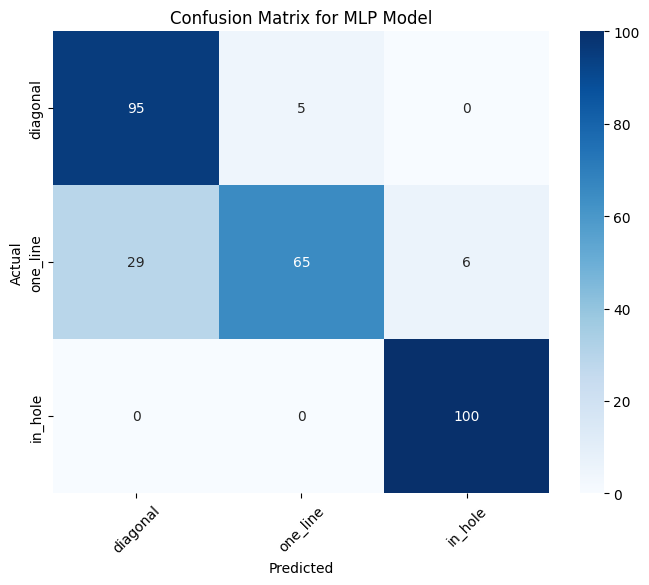

In [58]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labellist, yticklabels=labellist)
plt.xlabel('Predicted',)
plt.xticks(rotation=45)
plt.ylabel('Actual')
plt.title('Confusion Matrix for MLP Model')
plt.show()

In [ ]:

# file_paths_train = [f"output_{i}.csv" for i in range(len(X_train))]
# file_paths_test = [f"output_{i}.csv" for i in range(len(X_test))]

# def compute_distances(X_train, y_train, X_test, y_test, y_pred):
#     results = []

#     for i, (true_label, predicted_label) in enumerate(zip(y_test, y_pred)):
#         if true_label != predicted_label:  # Only for misclassified samples
#             x_test_sample = X_test[i]

#             # Compute distances to all X_train samples using the euclidean_distance function
#             for j, x_train_sample in enumerate(X_train):
#                 distance = np.sqrt(np.sum((np.array(x_train_sample) - np.array(x_test_sample))**2))
#                 results.append({
#                     "misclassified_test_index": i,
#                     "test_true_label": true_label,
#                     "test_predicted_label": predicted_label,
#                     "train_index": j,
#                     "train_label": y_train[j],
#                     "distance": distance
#                 })

#     return pd.DataFrame(results)

# distances_df = compute_distances(X_train, y_train, X_test, y_test, y_pred)
# # print(distances_df.iloc[809])

# closest_samples = distances_df.loc[distances_df.groupby("misclassified_test_index")["distance"].idxmin()]
# # print(closest_samples)

# closest_samples = closest_samples.copy()
# closest_samples["test_file_path"] = closest_samples["misclassified_test_index"].apply(lambda idx: file_paths_test[idx])
# closest_samples["train_file_path"] = closest_samples["train_index"].apply(lambda idx: file_paths_train[idx])

# print(closest_samples)
# # analyze_misclassified_data(X_test, y_test, y_pred, label=0)

In [ ]:
# # Visualization function
# def visualize_distances(distances_df):
#     """
#     Visualizes distances between misclassified test samples and training samples.

#     Parameters:
#     distances_df: pd.DataFrame - DataFrame containing distances and corresponding information.
#     """
#     # Scatter plot of distances
#     plt.figure(figsize=(12, 6))
#     plt.scatter(distances_df["misclassified_test_index"], distances_df["distance"], alpha=0.7)
#     plt.title("Distances Between Misclassified Test Samples and Training Samples")
#     plt.xlabel("Misclassified Test Index")
#     plt.ylabel("Distance")
#     plt.grid(True)
#     plt.show()

#     # Bar plot of closest distances only
#     closest_samples = distances_df.loc[distances_df.groupby("misclassified_test_index")["distance"].idxmin()]
#     plt.figure(figsize=(12, 6))
#     plt.bar(closest_samples["misclassified_test_index"], closest_samples["distance"], alpha=0.7)
#     plt.title("Closest Distances for Each Misclassified Test Sample")
#     plt.xlabel("Misclassified Test Index")
#     plt.ylabel("Closest Distance")
#     plt.grid(True)
#     plt.show()

# visualize_distances(distances_df)

In [ ]:
# csv_file_path = "/home/do-gon/vibecheck_ws/classification/smallest_distances_df.csv"
# closest_samples.to_csv(csv_file_path, index=False)

# csv_file_path

In [ ]:
# import os
# import pandas as pd

# # Define the path to the test set folder
# test_set_path = "/home/do-gon/vibecheck_ws/datas/Spring 2025/peg_in_hole_task/train_feb_1_feb_2_feb_11_feb_13_test_feb_2_feb_3_feb_11_demo_data/test_set"

# # Initialize a dictionary to store folder names and file counts
# file_counts = {}

# # Iterate through each subdirectory in the test set folder
# for folder in os.listdir(test_set_path):
#     folder_path = os.path.join(test_set_path, folder)
#     if os.path.isdir(folder_path):  # Ensure it's a directory
#         # Count the number of output_*.csv files
#         count = sum(1 for file in os.listdir(folder_path) if file.startswith("output_") and file.endswith(".csv"))
#         file_counts[folder] = count

# # Convert to DataFrame for better visualization
# df_file_counts = pd.DataFrame(list(file_counts.items()), columns=["Folder", "Output File Count"])

# # Save to a CSV file
# output_csv_path = os.path.join(test_set_path, "output_file_counts.csv")
# df_file_counts.to_csv(output_csv_path, index=False)

# # Display the result
# print(df_file_counts)
# print(f"\nResults saved to {output_csv_path}")

###################################################3
import os

# Define the path to the test set folder
test_set_path = "/home/do-gon/acoustic_docker/vibecheck_ws/classification/data/contact_type/2025-2-22/feb_22_demo_data/test_set"

# Initialize a dictionary to store folder names and file counts
file_counts = {}

# Iterate through each subdirectory in the test set folder
for folder in os.listdir(test_set_path):
    folder_path = os.path.join(test_set_path, folder)
    if os.path.isdir(folder_path):  # Ensure it's a directory
        # Count the number of output_*.csv files
        count = sum(1 for file in os.listdir(folder_path) if file.startswith("output_") and file.endswith(".csv"))
        file_counts[folder] = count

# Define the specified file order
# specified_order = [
#     "one_line_9", "one_line_0", "diagonal_2", "in_hole_8", "diagonal_6",
#     "one_line_1", "in_hole_3", "in_hole_10", "one_line_5", "diagonal_4",
#     "in_hole_9", "diagonal_5", "in_hole_4", "one_line_8", "one_line_2",
#     "in_hole_2", "one_line_10", "diagonal_10", "diagonal_3", "diagonal_7",
#     "in_hole_7", "diagonal_1", "one_line_3", "one_line_6", "in_hole_1",
#     "one_line_7", "in_hole_5", "in_hole_6", "one_line_4", "diagonal_9",
#     "diagonal_8"
# ]

specified_order = [
    "one_line_9", "diagonal_2", "in_hole_8", "diagonal_6", #"one_line_9", "one_line_0","diagonal_2", "in_hole_8", "diagonal_6",
    "one_line_1", "in_hole_3", "in_hole_10", "one_line_5", "diagonal_4",
    "in_hole_9", "diagonal_5", "in_hole_4", "one_line_8", "one_line_2",
    "in_hole_2", "one_line_10", "diagonal_10", "diagonal_3", "diagonal_7",
    "in_hole_7", "diagonal_1", "one_line_3", "one_line_6", "in_hole_1",
    "one_line_7", "in_hole_5", "in_hole_6", "one_line_4", "diagonal_9",
    "diagonal_8"
]


# Initialize index tracking
specified_index_mapping = {}
df_all_dict = {}
current_index = 0

# # Assign index ranges based on the specified order
# for folder in specified_order:
#     count = file_counts.get(folder, 0)  # Get the count from file_counts
#     specified_index_mapping[folder] = (current_index, current_index + count)
#     current_index += count

# Define the mapping for folder names to variable names
folder_name_mapping = {
    "diagonal": "df_all_diagonal",
    "one_line": "df_all_one_line",
    "in_hole": "df_all_in_hole"
}

# # Print the slicing statements with corresponding variable names
# for folder, (start, end) in specified_index_mapping.items():
#     for key in folder_name_mapping:
#         if folder.startswith(key):
#             variable_name = f"{folder_name_mapping[key]}_{folder.split('_')[-1]}"
#             print(f"{variable_name} = df_all2.iloc[:, {start}:{end}]")
#             break

# Assign index ranges based on the specified order
for folder in specified_order:
    count = file_counts.get(folder, 0)  # Get the count from file_counts
    start, end = current_index, current_index + count
    specified_index_mapping[folder] = (start, end)
    current_index = end  # Update index for next folder

    # Generate variable name and print slicing statement
    for key in folder_name_mapping:
        if folder.startswith(key):
            variable_name = f"{folder_name_mapping[key]}_{folder.split('_')[-1]}"
            print(f"{variable_name} = df_all2.iloc[:, {start}:{end}]")
            df_all_dict[folder] = df_all2.iloc[:, start:end]  # Add to dictionary
            break





df_all_one_line_9 = df_all2.iloc[:, 0:10]
df_all_diagonal_2 = df_all2.iloc[:, 10:20]
df_all_in_hole_8 = df_all2.iloc[:, 20:30]
df_all_diagonal_6 = df_all2.iloc[:, 30:40]
df_all_one_line_1 = df_all2.iloc[:, 40:50]
df_all_in_hole_3 = df_all2.iloc[:, 50:60]
df_all_in_hole_10 = df_all2.iloc[:, 60:70]
df_all_one_line_5 = df_all2.iloc[:, 70:80]
df_all_diagonal_4 = df_all2.iloc[:, 80:90]
df_all_in_hole_9 = df_all2.iloc[:, 90:100]
df_all_diagonal_5 = df_all2.iloc[:, 100:110]
df_all_in_hole_4 = df_all2.iloc[:, 110:120]
df_all_one_line_8 = df_all2.iloc[:, 120:130]
df_all_one_line_2 = df_all2.iloc[:, 130:140]
df_all_in_hole_2 = df_all2.iloc[:, 140:150]
df_all_one_line_10 = df_all2.iloc[:, 150:160]
df_all_diagonal_10 = df_all2.iloc[:, 160:170]
df_all_diagonal_3 = df_all2.iloc[:, 170:180]
df_all_diagonal_7 = df_all2.iloc[:, 180:190]
df_all_in_hole_7 = df_all2.iloc[:, 190:200]
df_all_diagonal_1 = df_all2.iloc[:, 200:210]
df_all_one_line_3 = df_all2.iloc[:, 210:220]
df_all_one_line_6 = df_all2.iloc[:

In [ ]:
########### show details of test set accuracy #######################
# order
#1 in_hole in_hole_5
#2 one_line one_line_4
#3 diagonal diagonal_2
#4 in_hole in_hole_6
#5 one_line one_line_1
#6 diagonal diagonal_5
#7 one_line one_line_5
#8 one_line one_line_6
#9 diagonal diagonal_3
#10 diagonal diagonal_6
#11 in_hole in_hole_4
#12 in_hole in_hole_2
#13 in_hole in_hole_1
#14 one_line one_line_3
#15 one_line one_line_2
#16 diagonal diagonal_4
#17 in_hole in_hole_3
#18 diagonal diagonal_1

# df_all_diagonal_1 = df_all2.iloc[:, 85:90]        # diagonal_1 [850:900]
# df_all_diagonal_2 = df_all2.iloc[:, 10:15]        # diagonal_2 [100:150]
# df_all_diagonal_3 = df_all2.iloc[:, 40:45]        # diagonal_3 [400:450]
# df_all_diagonal_4 = df_all2.iloc[:, 75:80]        # diagonal_4 [750:800]
# df_all_diagonal_5 = df_all2.iloc[:, 25:30]        # diagonal_5 [250:300] 
# df_all_diagonal_6 = df_all2.iloc[:, 45:50]        # diagonal_6 [450:500]

# df_all_one_line_1 = df_all2.iloc[:, 20:25]        # one_line_1 [200:250]
# df_all_one_line_2 = df_all2.iloc[:, 70:75]        # one_line_2 [700:750] 
# df_all_one_line_3 = df_all2.iloc[:, 65:70]        # one_line_3 [650:700]
# df_all_one_line_4 = df_all2.iloc[:, 5:10]        # one_line_4 [50:100]
# df_all_one_line_5 = df_all2.iloc[:, 30:35]        # one_line_5 [300:350]
# df_all_one_line_6 = df_all2.iloc[:, 35:40]        # one_line_6 [350:400] 

# df_all_in_hole_1 = df_all2.iloc[:, 60:65]        # in_hole_1 [600:650] 
# df_all_in_hole_2 = df_all2.iloc[:, 55:60]        # in_hole_2 [550:600]
# df_all_in_hole_3 = df_all2.iloc[:, 80:85]        # in_hole_3 [800:850]
# df_all_in_hole_4 = df_all2.iloc[:, 50:55]        # in_hole_4 [500:550]
# df_all_in_hole_5 = df_all2.iloc[:, 0:5]        # in_hole_5 [0:50]
# df_all_in_hole_6 = df_all2.iloc[:, 15:20]        # in_hole_6 [150:200]

# randdd = df_all2.iloc[:, 89] 

# df_all_diagonal_10 = df_all2.iloc[:, 0:29]
# df_all_in_hole_5 = df_all2.iloc[:, 29:49]
# df_all_one_line_4 = df_all2.iloc[:, 49:69]
# df_all_diagonal_2 = df_all2.iloc[:, 69:98]
# df_all_one_line_8 = df_all2.iloc[:, 98:118]
# df_all_one_line_7 = df_all2.iloc[:, 118:138]
# df_all_in_hole_6 = df_all2.iloc[:, 138:158]
# df_all_one_line_1 = df_all2.iloc[:, 158:178]
# df_all_diagonal_5 = df_all2.iloc[:, 178:207]
# df_all_one_line_10 = df_all2.iloc[:, 207:227]
# df_all_one_line_5 = df_all2.iloc[:, 227:247]
# df_all_one_line_6 = df_all2.iloc[:, 247:267]
# df_all_in_hole_9 = df_all2.iloc[:, 267:287]
# df_all_in_hole_8 = df_all2.iloc[:, 287:307]
# df_all_diagonal_3 = df_all2.iloc[:, 307:336]
# df_all_one_line_9 = df_all2.iloc[:, 336:356]
# df_all_diagonal_6 = df_all2.iloc[:, 356:385]
# df_all_diagonal_8 = df_all2.iloc[:, 385:414]
# df_all_in_hole_4 = df_all2.iloc[:, 414:434]
# df_all_in_hole_10 = df_all2.iloc[:, 434:454]
# df_all_in_hole_2 = df_all2.iloc[:, 454:474]
# df_all_in_hole_1 = df_all2.iloc[:, 474:494]
# df_all_one_line_3 = df_all2.iloc[:, 494:514]
# df_all_one_line_2 = df_all2.iloc[:, 514:534]
# df_all_diagonal_7 = df_all2.iloc[:, 534:563]
# df_all_in_hole_7 = df_all2.iloc[:, 563:583]
# df_all_diagonal_4 = df_all2.iloc[:, 583:612]
# df_all_in_hole_3 = df_all2.iloc[:, 612:632]
# df_all_diagonal_9 = df_all2.iloc[:, 632:661]
# df_all_diagonal_1 = df_all2.iloc[:, 661:690]

# df_all_diagonal_5 = df_all2.iloc[:, 0:20]

In [60]:
# Iterate over all datasets and classify
import numpy as np

for name, df3 in df_all_dict.items():
    df3 = df3.T  # Transpose the dataset
    if "label" not in df3.columns:
        print(f"Skipping {name}: 'label' column missing")
        continue
    
    X2 = df3.drop("label", axis=1)
    y2 = df3["label"].astype(int)

    X_test, y_test = X2, y2
    X_test = kpca.transform(X_test)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    # print(f"{name} accuracy: {accuracy * 100:.2f}%")
    # print(f"Classified results for {name}: {y_pred}\n")
    variable_name = name.replace(" ", "_")  # Replace spaces with underscores if any
    formatted_output = f"{variable_name} = np.array({y_pred.tolist()})"

    print(formatted_output)


one_line_9 = np.array([0, 0, 0, 1, 1, 1, 1, 1, 0, 1])
diagonal_2 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
in_hole_8 = np.array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
diagonal_6 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
one_line_1 = np.array([0, 1, 0, 0, 0, 0, 1, 1, 1, 1])
in_hole_3 = np.array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
in_hole_10 = np.array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
one_line_5 = np.array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1])
diagonal_4 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
in_hole_9 = np.array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
diagonal_5 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
in_hole_4 = np.array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
one_line_8 = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1])
one_line_2 = np.array([1, 0, 1, 1, 0, 1, 1, 0, 1, 1])
in_hole_2 = np.array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
one_line_10 = np.array([2, 2, 1, 2, 1, 1, 2, 1, 2, 2])
diagonal_10 = np.array([1, 0, 0, 0, 0, 1, 0, 0, 0, 1])
diagonal_3 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
diagonal_7 = np.array([0, 0, 1,

In [ ]:

print("0--diagonal  1--one_line  2--in_hole")

# df3 = df_all_diagonal_1.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"diagonal_1 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_diagonal_2.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"diagonal_2 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")


# df3 = df_all_diagonal_3.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"diagonal_3 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_diagonal_4.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"diagonal_4 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_diagonal_5.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"diagonal_5 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_diagonal_6.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"diagonal_6 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_one_line_1.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)
# # print('y2:', y2)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"one_line_1 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_one_line_2.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)
# # print('y2:', y2)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"one_line_2 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_one_line_3.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)
# # print('y2:', y2)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"one_line_3 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_one_line_4.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)
# # print('y2:', y2)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"one_line_4 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_one_line_5.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)
# # print('y2:', y2)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"one_line_5 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_one_line_6.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)
# # print('y2:', y2)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"one_line_6 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_in_hole_1.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"in_hole_1 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_in_hole_2.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"in_hole_2 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_in_hole_3.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"in_hole_3 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_in_hole_4.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"in_hole_4 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_in_hole_5.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"in_hole_5 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

# df3 = df_all_in_hole_6.T
# X2=df3.drop("label",axis=1)
# y2=df3["label"].astype(int)

# X_test, y_test = X2,y2
# X_test = kpca.transform(X_test)
# y_pred=clf.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(f"in_hole_6 accuracy: {accuracy * 100:.2f}%")
# print(f"classified results: {y_pred}")

0--diagonal  1--one_line  2--in_hole


In [ ]:
# print("Classification Report:")
# print(classification_report(y_test, y_pred, target_names=labellist))
# temp=classification_report(y_test, y_pred, target_names=labellist, output_dict=True)
# output=pd.DataFrame(temp)

In [ ]:
# import seaborn as sns
# from sklearn.metrics import confusion_matrix

In [ ]:
# cm = confusion_matrix(y_test, y_pred)

# # Plot confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labellist, yticklabels=labellist)
# plt.xlabel('Predicted',)
# plt.xticks(rotation=45)
# plt.ylabel('Actual')
# plt.title('Confusion Matrix for MLP Model')
# plt.show()

In [ ]:
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy * 100:.2f}%")

In [ ]:
output.T.to_csv('contact_withoutPoint_train_11_04_test_11_04_after_fft.csv')

In [ ]:
import pickle
pickle.dump(clf, open("MLP_train_demo_process_below_8750_02_15", 'wb'))
pickle.dump(kpca, open("KPCA_train_demo_process_below_8750_02_15", 'wb'))

In [ ]:
my_model_clf = pickle.load(open("Knn_train_11_01", 'rb'))
result_score = my_model_clf.score(X_test,y_test)
print("Score: ",result_score)

Score:  0.8777777777777778


In [ ]:
X.shape

(900, 2500)

In [ ]:
X_test.shape

(90, 809)

In [ ]:
X_train.shape

(810, 809)